In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import glob
import os

In [95]:
def combine_csv_from_folder(folder_path):
    # Search for all csv files in the specified directory
    all_files = glob.glob(os.path.join(folder_path, "*.csv"))

    # List comprehension to read all files
    df_list = [pd.read_csv(f) for f in all_files]

    # Concatenate all files into one DataFrame
    combined_df = pd.concat(df_list, ignore_index=True)
    return combined_df

# Assuming your "UDAI Dataset" folder is in your current directory
# Adjust paths if you mounted Google Drive (e.g., '/content/drive/MyDrive/...')
df_biometric = combine_csv_from_folder('/content/sample_data/UDAI Dataset/Biometric')
df_demographic = combine_csv_from_folder('/content/sample_data/UDAI Dataset/Demographic')
df_enrolment = combine_csv_from_folder('/content/sample_data/UDAI Dataset/Enrolment')

Biometric Dataset

In [96]:
df_biometric.head()
df_biometric.info()
df_biometric.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   date          object
 1   state         object
 2   district      object
 3   pincode       int64 
 4   bio_age_5_17  int64 
 5   bio_age_17_   int64 
dtypes: int64(3), object(3)
memory usage: 85.2+ MB


,0
date,0
state,0
district,0
pincode,0
bio_age_5_17,0
bio_age_17_,0


In [97]:
list(df_biometric.columns)

['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']

Demographic Dataset  

In [98]:
df_demographic.head()
df_demographic.info()
df_demographic.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2071700 entries, 0 to 2071699
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   date           object
 1   state          object
 2   district       object
 3   pincode        int64 
 4   demo_age_5_17  int64 
 5   demo_age_17_   int64 
dtypes: int64(3), object(3)
memory usage: 94.8+ MB


,0
date,0
state,0
district,0
pincode,0
demo_age_5_17,0
demo_age_17_,0


In [99]:
list(df_demographic.columns)

['date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']

Enrolment Dataset

In [100]:
df_enrolment.head()
df_enrolment.info()
df_enrolment.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1029030 entries, 0 to 1029029
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1029030 non-null  object
 1   state           1029030 non-null  object
 2   district        1029030 non-null  object
 3   pincode         1029030 non-null  int64 
 4   age_0_5         1029030 non-null  int64 
 5   age_5_17        1029030 non-null  int64 
 6   age_18_greater  1029030 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 55.0+ MB


,0
date,0
state,0
district,0
pincode,0
age_0_5,0
age_5_17,0
age_18_greater,0


In [101]:
list(df_enrolment.columns)

['date',
 'state',
 'district',
 'pincode',
 'age_0_5',
 'age_5_17',
 'age_18_greater']

## **Data Visulatisation**

**Comparative Temporal Analysis**

This part of our analysis focuses on Time-Series Analysis, which is crucial for identifying "temporal patterns" as requested in problem statement. By analyzing data over time, we move from seeing a static snapshot to understanding the lifecycle of an Aadhaar identity.

**Multiline Chart**

This visualization tracks the volume of Enrollments, Demographic Updates, and Biometric Updates on the same X-axis (Time).

/tmp/ipython-input-870335724.py:13: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/tmp/ipython-input-870335724.py:14: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



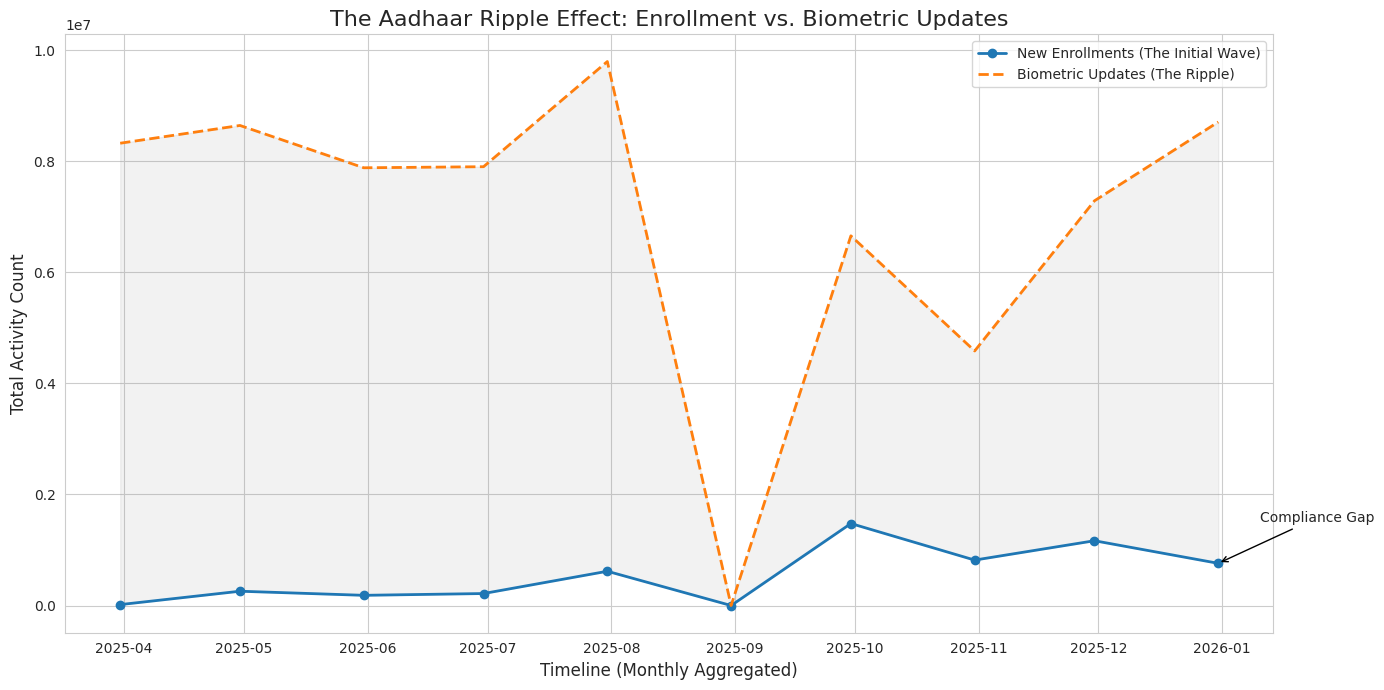

In [102]:
# 1. Ensure 'date' is in datetime format with correct parsing
# We use dayfirst=True to handle Indian date formats like 13-11-2025
df_enrolment['date'] = pd.to_datetime(df_enrolment['date'], dayfirst=True, errors='coerce')
df_biometric['date'] = pd.to_datetime(df_biometric['date'], dayfirst=True, errors='coerce')

# 2. Correctly aggregate age groups into new Count columns
# Ensure these column names match your actual CSV headers exactly
df_biometric['Biometric_Count'] = df_biometric['bio_age_5_17'] + df_biometric['bio_age_17_']
df_enrolment['Enrolment_Count'] = df_enrolment['age_0_5'] + df_enrolment['age_5_17'] + df_enrolment['age_18_greater']

# 3. Set 'date' as index for resampling
# We create a copy to avoid modifying the original dataframes accidentally
enrol_monthly = df_enrolment.set_index('date').resample('M')['Enrolment_Count'].sum()
bio_monthly = df_biometric.set_index('date').resample('M')['Biometric_Count'].sum()

# 4. Create the Visualization
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Plotting the 'Wave' and the 'Ripple'
plt.plot(enrol_monthly.index, enrol_monthly.values,
         label='New Enrollments (The Initial Wave)', color='#1f77b4', linewidth=2, marker='o')
plt.plot(bio_monthly.index, bio_monthly.values,
         label='Biometric Updates (The Ripple)', color='#ff7f0e', linewidth=2, linestyle='--')

# Adding Shaded Area for Visual "Gap Analysis"
# This highlights the difference between enrollment and mandatory update compliance
plt.fill_between(enrol_monthly.index, enrol_monthly.values, bio_monthly.values, color='gray', alpha=0.1)

# Formatting
plt.title('The Aadhaar Ripple Effect: Enrollment vs. Biometric Updates', fontsize=16)
plt.xlabel('Timeline (Monthly Aggregated)', fontsize=12)
plt.ylabel('Total Activity Count', fontsize=12)
plt.legend()

# 5. Annotation for insights
plt.annotate('Compliance Gap', xy=(enrol_monthly.index[-1], enrol_monthly.values[-1]),
             xytext=(30, 30), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

**Seasonal Heatmap**

A heatmap uses color intensity to represent the volume of activity across two dimensions, such as Months (Rows) and Days of the Week (Columns).

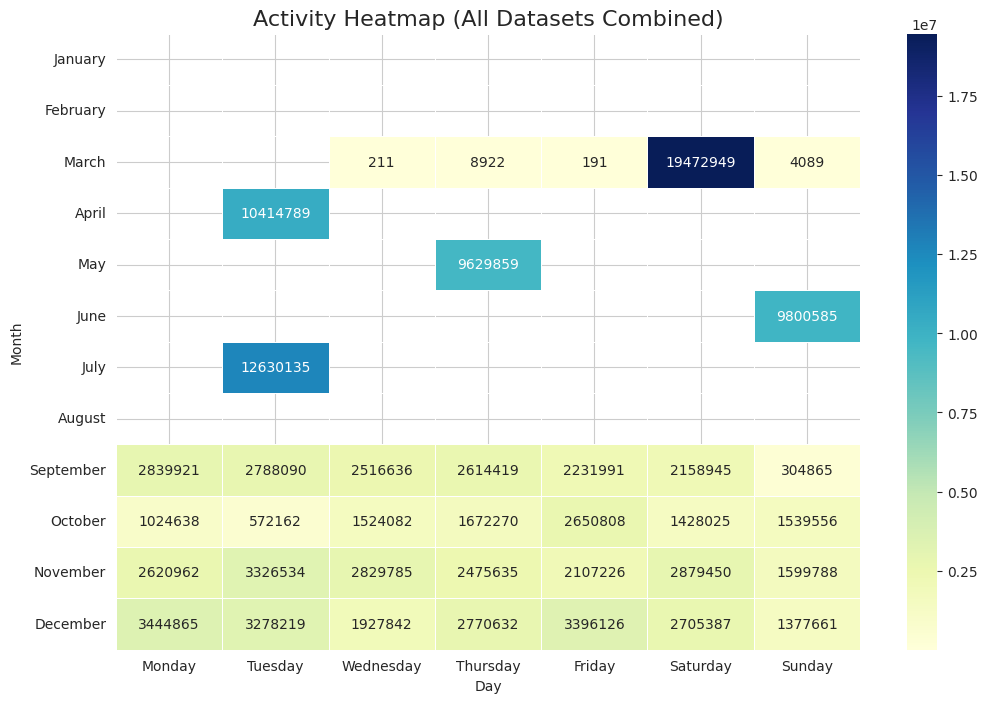

In [103]:
# --- STEP 1: Define the Folder Paths ---
# Ensure these match your Colab file explorer exactly
folders = {
    'Enrolment': '/content/sample_data/UDAI Dataset/Enrolment',
    'Biometric': '/content/sample_data/UDAI Dataset/Biometric',
    'Demographic': '/content/sample_data/UDAI Dataset/Demographic'
}

# --- STEP 2: Function to Load and Sum All Counts ---
def get_total_counts(folder_path):
    all_files = glob.glob(os.path.join(folder_path, "*.csv"))
    df_list = []
    for f in all_files:
        temp_df = pd.read_csv(f)
        # Convert date safely
        temp_df['date'] = pd.to_datetime(temp_df['date'], dayfirst=True, errors='coerce')

        # Identify numeric columns (the 'Counts') and sum them into one column
        count_cols = [col for col in temp_df.columns if 'age' in col or 'count' in col.lower()]
        temp_df['Folder_Total'] = temp_df[count_cols].sum(axis=1)

        df_list.append(temp_df[['date', 'Folder_Total']])

    return pd.concat(df_list, ignore_index=True)

# --- STEP 3: Combine All Three Categories ---
all_data = []
for name, path in folders.items():
    all_data.append(get_total_counts(path))

df_pulse = pd.concat(all_data, ignore_index=True)

# --- STEP 4: Prepare the Heatmap Grid ---
df_pulse['Month'] = df_pulse['date'].dt.month_name()
df_pulse['Day'] = df_pulse['date'].dt.day_name()

# Logical ordering for the axis
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot_table = df_pulse.pivot_table(values='Folder_Total',
                                   index='Month',
                                   columns='Day',
                                   aggfunc='sum').reindex(index=month_order, columns=day_order)

# --- STEP 5: Visualize ---
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=True, fmt=".0f", linewidths=.5)
plt.title('Activity Heatmap (All Datasets Combined)', fontsize=16)
plt.show()

# Geographical Stress Mapping

**Saturation Map**

In a district that is "Saturated" (everyone has an Aadhaar), we will see very few new enrollments and a massive number of updates. In an "Underserved" district, we will see a high number of new enrollments (especially in adults) relative to updates.The Calculation:$$Saturation Index = \frac{\text{Updates (Demographic + Biometric)}}{\text{Total Activity (Enrollment + Updates)}}$$High Index (near 1.0): Saturated. Most work is just maintaining existing IDs.Low Index (near 0): Underserved. The system is still busy creating new identities.

In [104]:
# --- STEP 1: CALCULATE TOTAL COUNTS (Strict Lower-case) ---
# Using the specific columns you provided for enrolment, biometric, and demographic
df_enrolment['enrolment_count'] = df_enrolment['age_0_5'] + df_enrolment['age_5_17'] + df_enrolment['age_18_greater']
df_biometric['biometric_count'] = df_biometric['bio_age_5_17'] + df_biometric['bio_age_17_']
df_demographic['demographic_count'] = df_demographic['demo_age_5_17'] + df_demographic['demo_age_17_']

# --- STEP 2: GEOGRAPHIC AGGREGATION ---
enrol_geo = df_enrolment.groupby(['state', 'district'])['enrolment_count'].sum().reset_index()
bio_geo = df_biometric.groupby(['state', 'district'])['biometric_count'].sum().reset_index()
demo_geo = df_demographic.groupby(['state', 'district'])['demographic_count'].sum().reset_index()

# --- STEP 3: MERGE INTO df_final ---
df_final = pd.merge(enrol_geo, bio_geo, on=['state', 'district'], how='outer')
df_final = pd.merge(df_final, demo_geo, on=['state', 'district'], how='outer').fillna(0)

# --- STEP 4: CALCULATE STRESS & SATURATION ---
df_final['total_updates'] = df_final['biometric_count'] + df_final['demographic_count']
df_final['total_activity'] = df_final['total_updates'] + df_final['enrolment_count']
df_final['saturation_index'] = df_final['total_updates'] / df_final['total_activity'].replace(0, 1)

# --- STEP 5: PREPARE FILTERED DATA ---
# Fix: Using > 0 ensures the hierarchy plot has "weights" to calculate
df_clean = df_final[df_final['enrolment_count'] > 0].copy()

# --- STEP 6: PROFESSIONAL STATE-WISE VISUALIZATION (SUNBURST) ---
# This is "different" and much better for state-to-district navigation
if not df_clean.empty:
    fig = px.sunburst(
        df_clean,
        path=['state', 'district'],
        values='enrolment_count',
        color='saturation_index',
        color_continuous_scale='RdYlGn', # Red = Needs help, Green = Saturated
        title="<b>Aadhaar Saturation Architecture: State-to-District Breakdown</b><br><sup>Click on a state to 'Drill Down' and see its specific 'Service Deserts' (Red blocks)</sup>",
        labels={'enrolment_count': 'New Enrollments', 'saturation_index': 'Saturation Score'}
    )

    fig.update_layout(
        margin=dict(t=80, l=0, r=0, b=0),
        height=700
    )
    fig.show()

    # --- SECOND PLOT: STATE-LEVEL BENCHMARKING ---
    # To make it truly "state-wise", we add a plot comparing average saturation across states
    state_avg = df_final.groupby('state')['saturation_index'].mean().reset_index().sort_values('saturation_index')

    fig_state = px.bar(
        state_avg,
        x='saturation_index',
        y='state',
        orientation='h',
        color='saturation_index',
        color_continuous_scale='RdYlGn',
        title="<b>State Ranking: Average Aadhaar Saturation</b>",
        labels={'saturation_index': 'Avg Saturation', 'state': 'State'}
    )
    fig_state.show()

else:
    print("ZeroDivisionError avoided: No valid data found for plotting.")

**Update-to-Enrollment Ratio**

In [105]:
# --- STEP 1: CALCULATE TOTALS ---
df_enrolment['enrolment_count'] = df_enrolment['age_0_5'] + df_enrolment['age_5_17'] + df_enrolment['age_18_greater']
df_biometric['biometric_count'] = df_biometric['bio_age_5_17'] + df_biometric['bio_age_17_']
df_demographic['demographic_count'] = df_demographic['demo_age_5_17'] + df_demographic['demo_age_17_']

# --- STEP 2: AGGREGATE AND MERGE ---
enrol_geo = df_enrolment.groupby(['state', 'district'])['enrolment_count'].sum().reset_index()
bio_geo = df_biometric.groupby(['state', 'district'])['biometric_count'].sum().reset_index()
demo_geo = df_demographic.groupby(['state', 'district'])['demographic_count'].sum().reset_index()

df_final = pd.merge(enrol_geo, bio_geo, on=['state', 'district'], how='outer')
df_final = pd.merge(df_final, demo_geo, on=['state', 'district'], how='outer').fillna(0)

# --- STEP 3: CREATE COMBINED LABEL & CALCULATE RATIO ---
# Combine District and State for a cleaner Y-axis
df_final['location_label'] = df_final['district'] + " (" + df_final['state'] + ")"

df_final['total_updates'] = df_final['biometric_count'] + df_final['demographic_count']
df_final['uer_ratio'] = df_final['total_updates'] / (df_final['enrolment_count'] + 1)

# --- STEP 4: VISUALIZE ---
top_hubs = df_final.sort_values(by='uer_ratio', ascending=False).head(15)

fig = px.bar(
    top_hubs,
    x='uer_ratio',
    y='location_label',  # Using the new combined label
    color='uer_ratio',
    orientation='h',
    color_continuous_scale='OrRd',
    title="<b>Top Migration Hubs: Update-to-Enrollment Ratio</b>",
    labels={'uer_ratio': 'Updates per Enrollment', 'location_label': 'District (State)'}
)

# Sort the bars so the highest ratio is at the top
fig.update_layout(yaxis={'categoryorder':'total ascending'}, height=600)
fig.show()

# Demographic & Age-Group Insights

**Age-Group Pyramid**

A bar chart (or pyramid) showing new enrollments across the three age buckets reveals the maturity of the Aadhaar ecosystem.

/tmp/ipython-input-2151352542.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




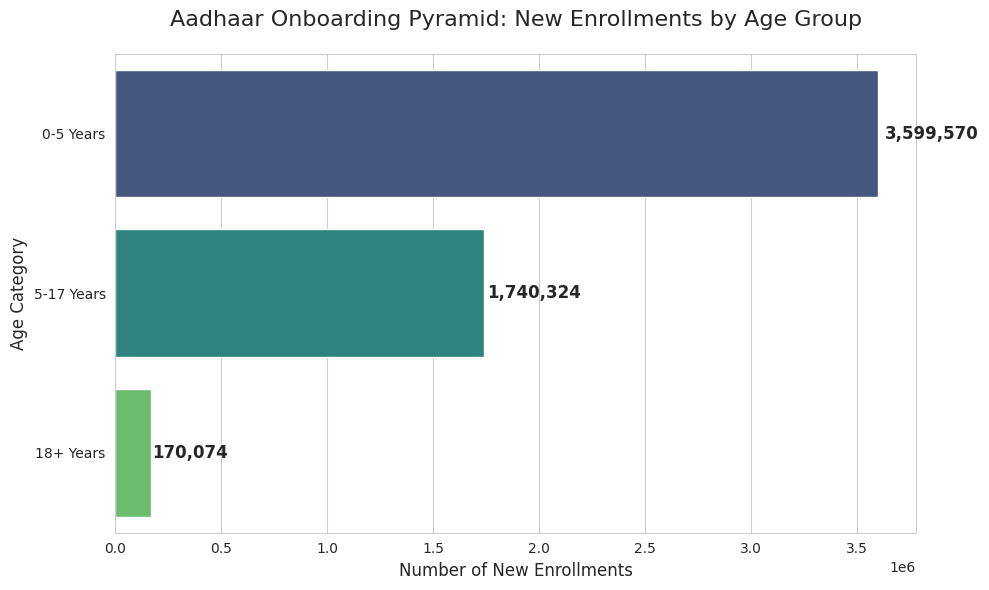

In [106]:
# --- STEP 1: PREPARE DATA ---
# Aggregate total enrollments for each age bucket
age_data = {
    'Age Group': ['0-5 Years', '5-17 Years', '18+ Years'],
    'Enrollment Count': [
        df_enrolment['age_0_5'].sum(),
        df_enrolment['age_5_17'].sum(),
        df_enrolment['age_18_greater'].sum()
    ]
}

df_pyramid = pd.DataFrame(age_data)

# --- STEP 2: GENERATE THE PYRAMID CHART ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create a horizontal bar chart
ax = sns.barplot(
    x='Enrollment Count',
    y='Age Group',
    data=df_pyramid,
    palette="viridis"
)

# Add data labels for clarity
for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + (width * 0.01),
        p.get_y() + p.get_height() / 2,
        '{:,.0f}'.format(width),
        ha='left',
        va='center',
        fontsize=12,
        fontweight='bold'
    )

# Formatting
plt.title('Aadhaar Onboarding Pyramid: New Enrollments by Age Group', fontsize=16, pad=20)
plt.xlabel('Number of New Enrollments', fontsize=12)
plt.ylabel('Age Category', fontsize=12)
plt.tight_layout()

plt.show()

**Biometric Compliance Funnel**

This is a critical "Stress Indicator." Aadhaar rules require children to update their biometrics (fingerprints/iris) once they reach ages 5 and 15.

In [107]:
# --- STEP 1: AGGREGATE FUNNEL DATA ---
# Extracting the 5-17 age group from both datasets
enrolled_youth = df_enrolment['age_5_17'].sum()
updated_youth = df_biometric['bio_age_5_17'].sum()

# Create the funnel stages
stages = ["Initial Enrollment (5-17 yrs)", "Mandatory Biometric Update"]
values = [enrolled_youth, updated_youth]

# --- STEP 2: GENERATE THE FUNNEL CHART ---
fig = go.Figure(go.Funnel(
    y = stages,
    x = values,
    textposition = "inside",
    textinfo = "value+percent initial",
    opacity = 0.85,
    marker = {"color": ["#636EFA", "#EF553B"],
              "line": {"width": [4, 2], "color": ["wheat", "wheat"]}},
    connector = {"line": {"color": "royalblue", "dash": "dot", "width": 3}}
))

fig.update_layout(
    title_text="<b>Biometric Compliance Funnel</b><br><sup>Visualizing the  Gap in Youth Biometric Updates</sup>",
    title_x=0.5,
    height=500
)

fig.show()

# Anomaly & Outlier Detection

**Box Plots for PIN Code Activity**

A box plot is used to show the distribution of data based on a five-number summary: minimum, first quartile, median, third quartile, and maximum.

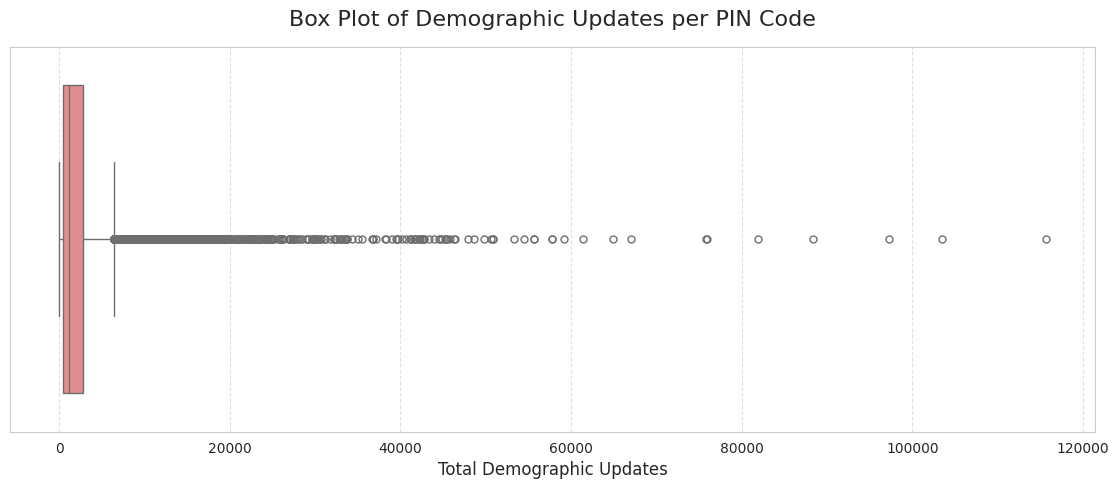

Summary Statistics:
- Median Updates: 1139.0
- Outlier Threshold: 6388.5
- Total Anomalous PIN Codes: 1786


In [108]:
# --- STEP 1: AGGREGATE ACTIVITY BY PIN CODE ---
# We group by pincode and sum the demographic_count we calculated earlier
pin_activity = df_demographic.groupby('pincode')['demographic_count'].sum().reset_index()

# --- STEP 2: GENERATE THE BOX PLOT ---
plt.figure(figsize=(14, 5))
sns.set_style("whitegrid")

# Creating a horizontal box plot to highlight outliers clearly
ax = sns.boxplot(x=pin_activity['demographic_count'], color='lightcoral', fliersize=5)

# Adding titles and labels
plt.title('Box Plot of Demographic Updates per PIN Code', fontsize=16, pad=15)
plt.xlabel('Total Demographic Updates', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

# --- STEP 3: STATISTICAL IDENTIFICATION OF ANOMALIES ---
# Calculate the Interquartile Range (IQR) to find the exact outlier threshold
Q1 = pin_activity['demographic_count'].quantile(0.25)
Q3 = pin_activity['demographic_count'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR

# Filter the PIN codes that are statistically anomalous
anomalies = pin_activity[pin_activity['demographic_count'] > outlier_threshold]

print(f"Summary Statistics:")
print(f"- Median Updates: {pin_activity['demographic_count'].median()}")
print(f"- Outlier Threshold: {outlier_threshold}")
print(f"- Total Anomalous PIN Codes: {len(anomalies)}")

**Scatter Plot: Demographic vs. Biometric Updates**

A scatter plot helps you see the relationship (correlation) between two different variables. In a healthy operational environment, districts with high demographic activity usually have a proportional amount of biometric activity.

In [109]:
# 1. CALCULATE CORRELATION
# A score near 1.0 means the infrastructure is perfectly balanced.
correlation = df_final['demographic_count'].corr(df_final['biometric_count'])

# 2. CREATE INTERACTIVE SCATTER PLOT
fig = px.scatter(
    df_final,
    x='demographic_count',
    y='biometric_count',
    color='state',         # Helps identify state-wide infrastructure patterns
    hover_name='district', # Shows district name on hover
    trendline="ols",       # Requires: pip install statsmodels
    title=f"<b>Aadhaar Operational Correlation: Demographic vs. Biometric Updates</b><br><sup>Current System Correlation: {correlation:.2f}</sup>",
    labels={
        'demographic_count': 'Total Demographic Updates',
        'biometric_count': 'Total Biometric Updates'
    },
    template="plotly_white"
)

# Optional: Make the trendline more visible
fig.update_traces(marker=dict(size=12, opacity=0.7))

fig.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning:

invalid value encountered in scalar divide

